# RAG from scratch

### The problem

Somewhere in a company wiki, a support archive, or a codebase nobody has read end to end,
there is a paragraph that answers your question. Two things stand between you and it.

**Keyword search makes you guess the author's words.** Search "wipe the database" and you
will miss the file that says `make reset`.

**A language model has never seen those documents.** Pasting them all into the prompt is
the obvious fix, and it fails as soon as the corpus outgrows the context window.

**So: find the few paragraphs most likely to answer the question, and paste only those.**
That finding step is retrieval, and it is where nearly all the engineering lives.
Sections 0-5 are about *find*. Section 6 covers what happens after, and 7 and 8 are what
you would hit next in a real system.

### Why this corpus

13 markdown files I wrote, far too small to actually need any of this. That is the point:
it is a test bed, not a use case. Checking whether a search result is *right* means
knowing the material well enough to tell, and on an unfamiliar corpus that is the
expensive part, which is why so many RAG demos stop before the evaluation.

No framework, no vector database, no API keys. The embedding model and the reranker are
ordinary library calls, since writing those yourself teaches nothing; everything between
them is written out so you can read it. Where a piece has an obvious production
equivalent, an *In production* note says so on the spot. A refresher and exploration for
me, shared along the way.

### Four words used throughout

- **Corpus**: the documents being searched. Here, 13 markdown files.
- **Chunk**: one searchable piece of a document. Retrieval returns chunks, not files, and
  a chunk is what ends up in the prompt.
- **Embedding**: a list of numbers a neural network produces for text, arranged so
  similar *meaning* gets similar numbers. That last part is the trick.
- **Retrieval**: ranking every chunk by how likely it is to answer the question, and
  keeping the top few.

There are two ways to rank, and this notebook uses both. **By keyword**, matching words
the question literally contains, which is decades old and still works. And **by meaning**,
matching "wipe my local database" to `make reset` despite no shared words, which is the
recent part. Each wins on different questions.

Assumed background is Python and numpy, specifically that `@` is a dot product. Softmax,
attention and BM25 get built as they come up.

### Refresher: where RAG sits in the ML landscape

*Skip if you have this map already.*

**Three ways a model learns.** *Supervised* learning trains on labelled examples: here is
an email, here is whether it is spam. *Unsupervised* finds structure in unlabelled data,
like the PCA in section 2 grouping chunks nobody told it about. *Reinforcement* learns
from a reward signal rather than answers, which is how models learn to play games, and how
the final polish on chat models is done.

**Traditional ML versus deep learning.** Logistic regression, decision trees and gradient
boosting learn from features you engineer by hand, and they still win on tabular data.
Deep learning stacks many layers of learned transformations and works out its own
features, which is what made text and images tractable. Transformers, from section 0, are
deep learning.

**Where the pieces here sit.** BM25 does not learn at all: it is arithmetic over word
counts from the 1990s. The embedding model is deep learning, pretrained on a large corpus
then tuned on sentence pairs. The cross-encoder in section 4 is supervised, trained on
labelled query and document pairs.

**And RAG itself is none of the above.** No training happens anywhere in this notebook. It
is an architecture: search, then paste into a prompt. That is exactly why it caught on,
because it gives a model access to your documents without the cost and risk of fine-tuning
one. The rough rule is that fine-tuning teaches a model new *behaviour*, and retrieval
gives it new *facts*. Most people reaching for the first actually want the second.

---
## 0. Scoring with vectors

Everything rests on one operation: score a question against a pile of candidates, keep the
best few. Three steps, numpy only. What you build is also, near enough, the attention
mechanism from the 2017 transformers paper, which gets a couple of lines at the end.

**Step one: scoring.** Suppose text can be turned into vectors so that similar meanings
point in similar directions. (Section 2 does this for real; here the vectors are made up
so the numbers stay readable.)

Then scoring is one dot product per candidate. Vectors pointing the same way score high,
different ways score low. In numpy that is `@`, and a matrix `@` a vector does every row
at once.

In [1]:
import numpy as np

# Four made-up 3-d vectors, one per word. Pretend an encoder produced them.
# The labels exist only so the output is readable.
labels = ["postgres", "database", "react", "flyer"]
K = np.array([[1.0, 0.0, 0.0],     # postgres
              [0.9, 0.1, 0.0],     # database - deliberately close to postgres
              [0.0, 1.0, 0.0],     # react    - pointing somewhere else entirely
              [0.0, 0.0, 1.0]])    # flyer    - somewhere else again

q = np.array([1.0, 0.0, 0.0])      # the question, pointing "postgres-ward"

scores = K @ q                     # one dot product per row, all four at once
for label, s in zip(labels, scores):
    print(f"{label:>10}  {s:.2f}")

  postgres  1.00
  database  0.90
     react  0.00
     flyer  0.00


`postgres` scores 1.00, `database` 0.90 because it was placed nearby, the two unrelated
words 0.

**Step two: scores into weights.** Attention *blends* rows rather than picking one, and
blending needs weights that are positive and add up to 1. The raw scores sum to 1.90 and
mean little as proportions.

**Softmax** fixes that in two moves: `np.exp` on every score, which makes everything
positive and stretches the gaps, then divide by the total so they sum to 1. The
`- x.max()` is only numerical safety, keeping `exp` from overflowing on large inputs.

In [2]:
def softmax(x):
    e = np.exp(x - x.max())        # the max subtraction is for numerical safety only
    return e / e.sum()

w = softmax(scores)
print("raw scores  ", scores.round(2))
print("as weights  ", w.round(3), "  sum:", w.sum().round(3))

# Scaling the scores before the softmax controls how sharp the result is. This is the
# temperature knob: bigger multiplier, more winner-take-all.
print()
for mult in (1, 4, 20):
    print(f"scores x{mult:<3} -> {softmax(scores * mult).round(3)}")

raw scores   [1.  0.9 0.  0. ]
as weights   [0.379 0.343 0.139 0.139]   sum: 1.0

scores x1   -> [0.379 0.343 0.139 0.139]
scores x4   -> [0.586 0.393 0.011 0.011]
scores x20  -> [0.881 0.119 0.    0.   ]


The same four numbers, drawn: both steps of the softmax on the left, and what the
sharpening knob does to them on the right. Plotting code lives in `figures.py`, since
matplotlib incantations are not the subject; everything that teaches retrieval stays
inline.

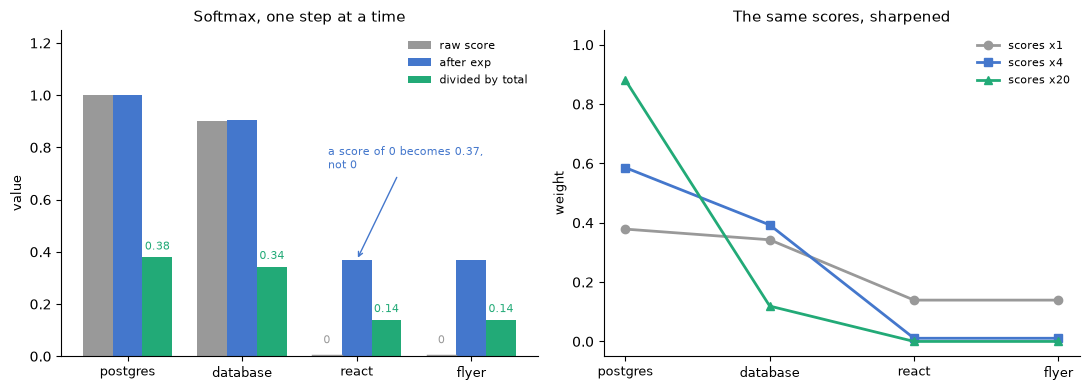

In [3]:
import figures

figures.softmax_steps(scores, labels, softmax)

At x1 the weights barely commit: 0.379 for the best match, still 0.139 for a word with
nothing in common. At x20 the best takes 0.881. Same scores, different sharpness.

**Step three: returning something.** Every row of `K` is a thing being searched *over*.
Attention gives each row a second vector, holding what to hand back if that row wins.
That is where the three names come from:

- **query**: what is being asked (our `q`)
- **key**: what each row is matched *on* (the rows of `K`)
- **value**: what each row hands *back* (the rows of `V`)

Keys and values stay separate so a row can be findable by one thing and return another.
Retrieval works the same way later: you match on chunk text, and hand back the chunk plus
its filename.

In [4]:
# Same four rows, now with something to return. Two numbers each, kept small so the
# blend is easy to read.
V = np.array([[10.0,  0.0],        # postgres
              [ 9.0,  1.0],        # database - a similar payload, as you would hope
              [ 0.0, 10.0],        # react
              [-5.0, -5.0]])       # flyer

weights = softmax((K @ q) * 4)     # score, then sharpen, then normalize
answer  = (weights[:, None] * V).sum(0)   # weighted average of the value rows

for label, weight in zip(labels, weights):
    print(f"{label:>10}  weight {weight:.3f}")
print("\nblended value:", answer.round(2))

  postgres  weight 0.586
  database  weight 0.393
     react  weight 0.011
     flyer  weight 0.011

blended value: [9.34 0.45]


The result sits close to the `postgres` and `database` payloads and almost ignores the
other two, which is the point: the output is mostly made of the rows that matched.

Laid out as columns, the whole operation fits on one screen.

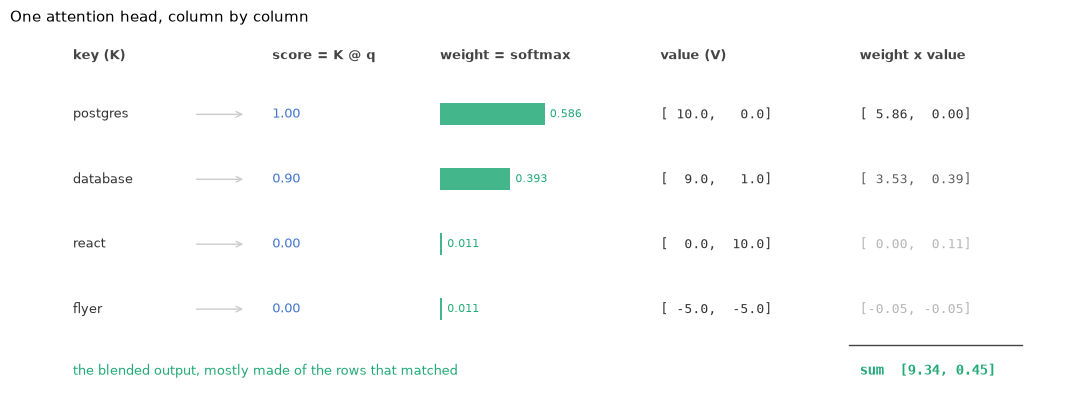

In [5]:
figures.attention_head(labels, scores, weights, V, answer)

That is one **attention head**, written compactly as `softmax(QKᵀ)V`. In a transformer
every word runs this same search against every other word, ending up holding a mixture of
whatever was relevant to it, and because they all look at once it parallelizes, which is
what the 2017 paper was really about.

So attention is already retrieval, over whatever sits in the context window. RAG is the
same move with a store too big to fit and hard weights: keep the top 5, drop the rest.

---
## 1. Chunking

Before anything can be searched, the documents have to be cut into pieces, because a
piece is what gets retrieved. It is the least glamorous part of RAG and the one that most
often decides whether it works.

Cut too small and a chunk loses the context that made it meaningful. Cut too large and
the embedding averages several topics into a vector close to none of them.

The split below goes on markdown headings first, since a heading is the author's own
mark for where one idea ends, then hard-wraps anything still too long.

In [6]:
import re, pathlib
from collections import Counter

CORPUS = pathlib.Path("corpus")
# Paths here are relative, so the notebook has to run from the repo root. Say so
# clearly rather than failing later with an empty-corpus error.
assert CORPUS.is_dir(), f"no corpus/ found from {pathlib.Path.cwd()} - run from the repo root"

def split_sections(text):
    # Split before a heading, so each piece keeps its own heading as a title.
    return [p.strip() for p in re.split(r"\n(?=#{1,3} )", text) if p.strip()]

def window(section, max_chars, overlap):
    # Overlap so a fact sitting on a cut line survives in at least one chunk whole.
    if len(section) <= max_chars:
        return [section]
    out, start = [], 0
    while start < len(section):
        out.append(section[start:start + max_chars])
        start += max_chars - overlap
    return out

def build_chunks(max_chars=900, overlap=150):
    chunks = []
    for path in sorted(CORPUS.glob("*.md")):
        for section in split_sections(path.read_text()):
            for piece in window(section, max_chars, overlap):
                chunks.append({"repo": path.name.split("__")[0],
                               "file": path.name,
                               "text": piece})
    return chunks

chunks = build_chunks()
print(f"{len(chunks)} chunks from {len(list(CORPUS.glob('*.md')))} files")
print(f"median length: {int(np.median([len(c['text']) for c in chunks]))} chars\n")
sample = next(c for c in chunks if c["text"].startswith("## Non-negotiables"))
print("---", sample["file"], "---")
print(sample["text"][:420])

199 chunks from 13 files
median length: 396 chars

--- secondhandplastic__CLAUDE.md ---
## Non-negotiables

These are promises made to users in `SECURITY.md`. Treat a change that breaks one as
a bug, not a tradeoff:

1. **A user's email is never rendered.** Not in a page, an API response, or a log.
   The public label is `display_name`. `tests/test_privacy.py` enforces this.
2. **Exact coordinates are never stored.** `app/geo.fuzz` jitters before write; the
   browser's precise value is dropped.
3. **Up


Most sections are short enough to pass through whole. The windowing only kicks in on the
long ones, and this is what it does to a section of 2300 characters.

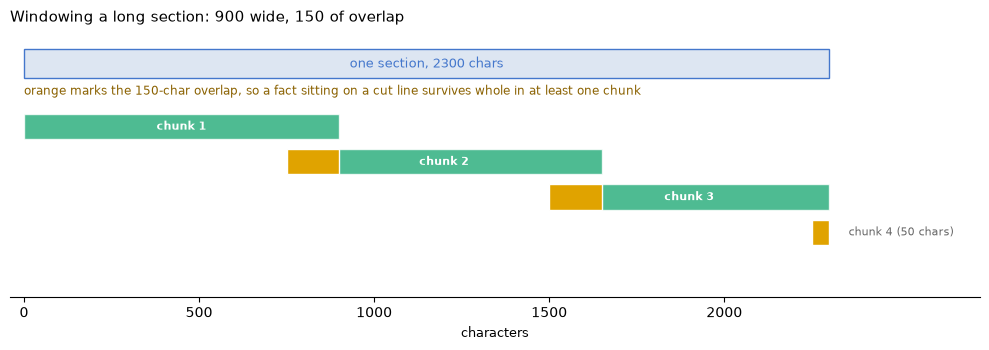

In [7]:
figures.chunk_windows(sec_len=2300, max_chars=900, overlap=150)

That last sliver is worth noticing. The loop steps forward by `max_chars - overlap`, so
whatever is left at the end becomes its own chunk however short it is, and a 50-character
chunk is unlikely to be retrieved for anything. Real chunkers usually fold a runt like
that back into the previous chunk.

*In production:* `RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)` from
LangChain does all of the above, including the runt handling.

---
## 2. Embedding

`all-MiniLM-L6-v2` is a small transformer: 6 layers, 22M parameters, the same kind of
attention stack as section 0 but trained to produce vectors rather than text. It runs on a
laptop CPU in seconds and downloads once (~90 MB).

Each word gets a vector, and the chunk's vector is their average: 384 numbers, scaled to
length 1. That scaling pays off immediately, because once every vector has length 1 the
dot product *is* the cosine similarity, so the whole search becomes one matrix multiply.

In [8]:
import logging
from transformers.utils import logging as hf_logging
from sentence_transformers import SentenceTransformer

logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
hf_logging.disable_progress_bar()   # keeps a stalled 0% bar out of the saved outputs

encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def embed(texts):
    return encoder.encode(texts, normalize_embeddings=True, batch_size=64,
                          show_progress_bar=False)

E = embed([c["text"] for c in chunks])
print("embedding matrix:", E.shape, "  ->", E.shape[0], "chunks x", E.shape[1], "dims")
print("every row is unit length:", np.allclose(np.linalg.norm(E, axis=1), 1.0))

embedding matrix: (199, 384)   -> 199 chunks x 384 dims
every row is unit length: True


### Is there structure in there?

Nobody can eyeball 384 numbers, but PCA (principal component analysis) finds the two
directions the data varies most along and flattens everything onto them, like a shadow of
a 384-dimensional object cast on a wall.

If the embeddings work, chunks from the same project should land near each other without
anyone having told the model which project they came from. A shadow loses information, so
treat clumping as encouraging rather than proof.

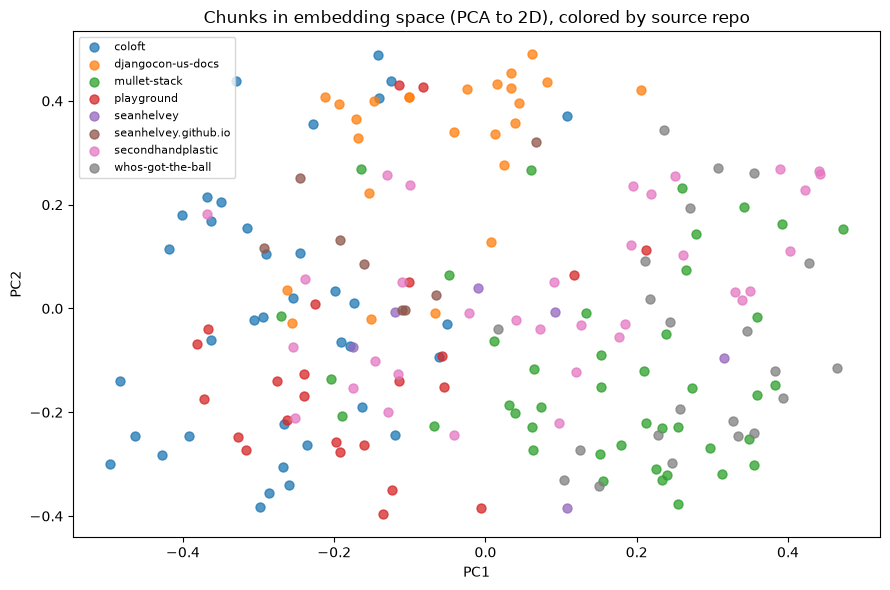

In [9]:
figures.embedding_space(E, chunks)

The interesting part is where clusters *overlap*. Anything about running a dev server
sits in the same neighbourhood whichever repo it came from, and that overlap is the
failure mode retrieval has to survive later.

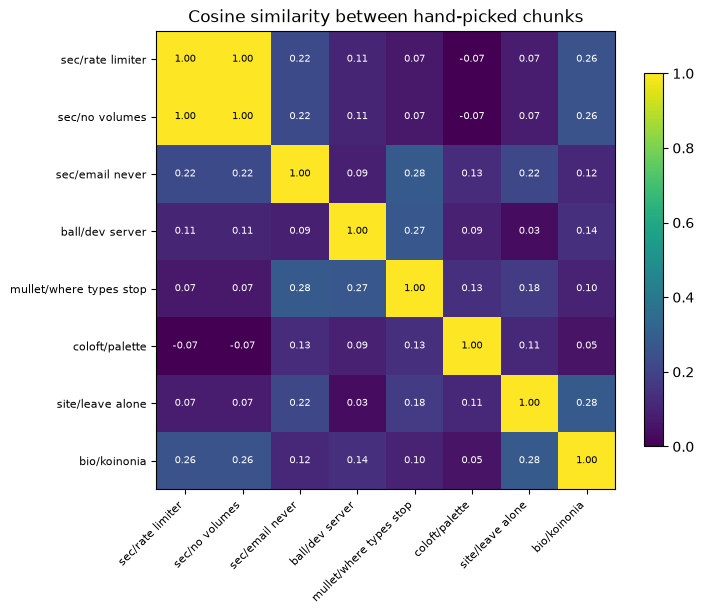

In [10]:
# Pick a few chunks by hand so the similarity matrix is readable.
def find(marker):
    return next(i for i, c in enumerate(chunks) if marker in c["text"])

picks = [
    ("sec/rate limiter", find("ratelimit.py")),
    ("sec/no volumes",   find("No persistent volumes")),
    ("sec/email never",  find("never rendered")),
    ("ball/dev server",  find("hot module reload")),
    ("mullet/where types stop", find("where the types stop")),
    ("coloft/palette",   find("Color Palette")),
    ("site/leave alone",  find("intentional, do not")),
    ("bio/koinonia",     find("Koinonia")),
]
names = [n for n, _ in picks]
S = E[[i for _, i in picks]] @ E[[i for _, i in picks]].T

figures.similarity_matrix(names, S)

Two things in that grid. The infrastructure chunks from one project score high together,
as hoped. And every pair scores at least 0.1, because these vectors encode "is written in
English about software" alongside the topic.

So **cosine similarity is not a probability.** A score of 0.45 means nothing alone, only
something relative to other scores for the same query, which makes a fixed similarity
threshold a shaky way to decide whether to answer.

---
## 3. Three ways to search

Each searcher scores every chunk, and keeping the results as plain score arrays makes
them easy to combine.

One convention matters downstream: these functions pass **positions** around, not chunks.
`top_k` returns indices, and `chunks[i]` gets the text back. Fusion, reranking and the
eval all shuffle indices, looking up text only at the end.

In [11]:
def dense_scores(query):
    q = embed([query])[0]
    return E @ q          # cosine similarity, because everything is unit length

def top_k(scores, k=5):
    # argsort returns the indices that *would* sort the array, not the sorted values.
    # It sorts ascending, so negating the scores flips it to descending. Net effect:
    # the positions of the k highest-scoring chunks, best first.
    return np.argsort(-scores)[:k]

demo = "why does the app avoid writing files to local disk?"
scores = dense_scores(demo)
print(f"query: {demo}\n")
for rank, i in enumerate(top_k(scores, 3), 1):
    flat = " ".join(chunks[i]["text"].split())      # collapse newlines so this reads as a list
    print(f"{rank}. {scores[i]:.3f}  {chunks[i]['file']}")
    print(f"   {flat[:88]}...")

query: why does the app avoid writing files to local disk?

1. 0.336  secondhandplastic__SECURITY.md
   path that stores an original file unaltered is a high-severity issue. 4. **Messages are ...
2. 0.297  secondhandplastic__SECURITY.md
   ## What this project promises its users These are the guarantees a vulnerability report ...
3. 0.290  secondhandplastic__CLAUDE.md
   ## Platform constraints that shape the code - **No persistent volumes.** Anything writte...


`E @ q` is the vector search. A vector database is that line plus storage, metadata
filtering, and an index that finds *approximately* the nearest vectors without scanning
every one, which starts to matter around 100 million rows. At 199 chunks an exact scan is
already faster.

If you have used **pgvector**, `ORDER BY embedding <=> $1` is doing the same cosine
comparison as this line, and the difference that matters is that the vectors sit beside
your relational data, so scoping a search to one repo becomes a `WHERE` clause.

Now the other half: **BM25**, a keyword-search default since the 1990s and still hard to
beat. It scores a chunk by the query words it literally contains, weighted by two ideas:

- **Term frequency**: a chunk mentioning "postgres" five times beats one mentioning it
  once.
- **Inverse document frequency (IDF)**: a word appearing in *every* chunk tells you
  nothing. "the" is worthless; "5433" is gold.

Plus two corrections. Term frequency **saturates**, so the 20th "postgres" adds almost
nothing over the 3rd, and long chunks are **penalized** so they cannot win just by being
big. `k1` and `b` below control those curves, at their standard defaults.

*In production:* the `rank_bm25` package, or Postgres full-text search. Note that Postgres
`ts_rank` is frequency-based rather than true BM25, and it is lexical only, with no
embeddings involved.

In [12]:
import math

def tokenize(s):
    return re.findall(r"[a-z0-9]+", s.lower())

def index_bm25(chunks):
    # Every statistic here depends on how the corpus was chunked, so this has to be
    # rebuilt whenever the chunking changes (see the regression demo in section 5).
    global docs, N, avgdl, tf, df, idf
    docs  = [tokenize(c["text"]) for c in chunks]
    N     = len(docs)
    avgdl = sum(len(d) for d in docs) / N
    tf    = [Counter(d) for d in docs]
    df    = Counter(t for d in docs for t in set(d))
    idf   = {t: math.log(1 + (N - n + 0.5) / (n + 0.5)) for t, n in df.items()}

index_bm25(chunks)

def bm25_scores(query, k1=1.5, b=0.75):
    scores = np.zeros(N)
    for term in tokenize(query):
        if term not in idf:
            continue                          # a word in no document scores nothing
        for i in range(N):
            f = tf[i][term]
            if f:
                dl = len(docs[i])
                scores[i] += idf[term] * f * (k1 + 1) / (f + k1 * (1 - b + b * dl / avgdl))
    return scores

# IDF in one look. This is the number that makes a rare token worth finding.
for term in ["the", "database", "postgres", "5433"]:
    print(f"{term:>10}  in {df[term]:>3} of {N} chunks   idf {idf[term]:.2f}")

       the  in 125 of 199 chunks   idf 0.47
  database  in  14 of 199 chunks   idf 2.62
  postgres  in  14 of 199 chunks   idf 2.62
      5433  in   2 of 199 chunks   idf 4.38


They fail in opposite directions, which is the reason to keep both. BM25 cannot get from
"wipe my local database" to `make reset`, with no shared words. Dense retrieval is the one
that struggles with rare exact tokens: `5433`, an error code, a customer ID, the things
people actually search for at work.

Adding the two score arrays together fails, since one is a cosine in [0,1] and the other
an unbounded sum of logs. **Reciprocal rank fusion** (RRF on the charts) sidesteps that by
discarding the scores and using only ranks: first place is first place whatever number
produced it.

*In production:* LangChain's `EnsembleRetriever`, which fuses any set of retrievers this
same way.

In [13]:
def rrf(rankings, k=5, K=60):
    # Each list votes 1/(K + rank) for what it put where. K=60 is the value from the
    # original paper; it damps the top of each list so one confident-but-wrong
    # ranker can't run away with the fusion.
    votes = Counter()
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            votes[idx] += 1 / (K + rank)
    return [i for i, _ in votes.most_common(k)]

def hybrid(query, k=5, pool=25):
    d = top_k(dense_scores(query), pool)
    s = top_k(bm25_scores(query), pool)
    return rrf([list(d), list(s)], k=k)

# Toy fusion, to see the voting before it runs on real rankings. C is nobody's
# favourite but appears in both lists, so it finishes above B, which only one liked.
print(rrf([["A", "B", "C"], ["C", "A", "D"]], k=4))

['A', 'C', 'B', 'D']


In [14]:
def show(query, k=5):
    d = top_k(dense_scores(query), k)
    s = top_k(bm25_scores(query), k)
    h = hybrid(query, k)
    print(f"query: {query}\n")
    print(f"{'#':<3}{'dense':<34}{'bm25':<34}{'hybrid (RRF)':<34}")
    print("-" * 105)
    for rank in range(k):
        row = [f"{chunks[col[rank]]['file'][:26]+'#'+str(col[rank]):<34}" for col in (d, s, h)]
        print(f"{rank+1:<3}" + "".join(row))

show("wipe my local database and start over")
print()
show("what port does local postgres listen on")

query: wipe my local database and start over

#  dense                             bm25                              hybrid (RRF)                      
---------------------------------------------------------------------------------------------------------
1  secondhandplastic__CLAUDE.#145    whos-got-the-ball__README.#193    secondhandplastic__CLAUDE.#145    
2  secondhandplastic__README.#159    secondhandplastic__CLAUDE.#145    whos-got-the-ball__README.#193    
3  whos-got-the-ball__README.#198    secondhandplastic__README.#162    secondhandplastic__CLAUDE.#144    
4  secondhandplastic__CLAUDE.#144    seanhelvey__README.md#140         djangocon-us-docs__README.#59     
5  playground__CLAUDE.md#107         coloft__README.md#2               secondhandplastic__README.#159    

query: what port does local postgres listen on

#  dense                             bm25                              hybrid (RRF)                      
---------------------------------------------------------

---
## 4. Reranking

Retrieval so far has a built-in limit. Chunk embeddings were computed *before* anyone
asked a question, which is what makes search fast, but it means a chunk's vector cannot
depend on the query. That arrangement is a **bi-encoder**: two separate passes, compared
by dot product.

A **cross-encoder** puts query and chunk into the model together, so attention sees both
and compares them token by token. Much more accurate, and far too slow for the whole
corpus: one forward pass per pair means 199 passes per question.

Hence the cheap-then-expensive cascade: retrieve 25 candidates fast, rerank those 25
slowly, keep 5.

In [15]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(query, idxs):
    scores = reranker.predict([(query, chunks[i]["text"]) for i in idxs])
    return [i for _, i in sorted(zip(scores, idxs), key=lambda p: -p[0])]

def hybrid_reranked(query, k=5, pool=25):
    return rerank(query, hybrid(query, k=pool, pool=pool))[:k]

# Same three chunks the dense search returned in section 3, rescored. A cross-encoder
# returns a raw relevance score (a "logit") rather than a cosine: it can be negative,
# has no fixed range, and only its ordering within one query means anything.
# Note which chunk it moves to the top.
for i in top_k(dense_scores(demo), 3):
    print(f"{reranker.predict([(demo, chunks[i]['text'])])[0]:+7.2f}  {chunks[i]['file']}")

 -10.70  secondhandplastic__SECURITY.md
  -9.21  secondhandplastic__SECURITY.md
  +0.02  secondhandplastic__CLAUDE.md


That is the cascade working on three chunks. Dense retrieval put two `SECURITY.md`
passages on top; the cross-encoder scores them −10.70 and −9.21 and puts the
`CLAUDE.md` chunk, the one that actually says "No persistent volumes", first at +0.02.
Same candidates, better order.

The scale is worth a second look. These are logits, so they run negative and have no
fixed range. Only their order within this one query carries information; the 0.336 from
the cosine and the +0.02 from the reranker are on different scales entirely.

The chart below shows the same reordering across a larger pool.

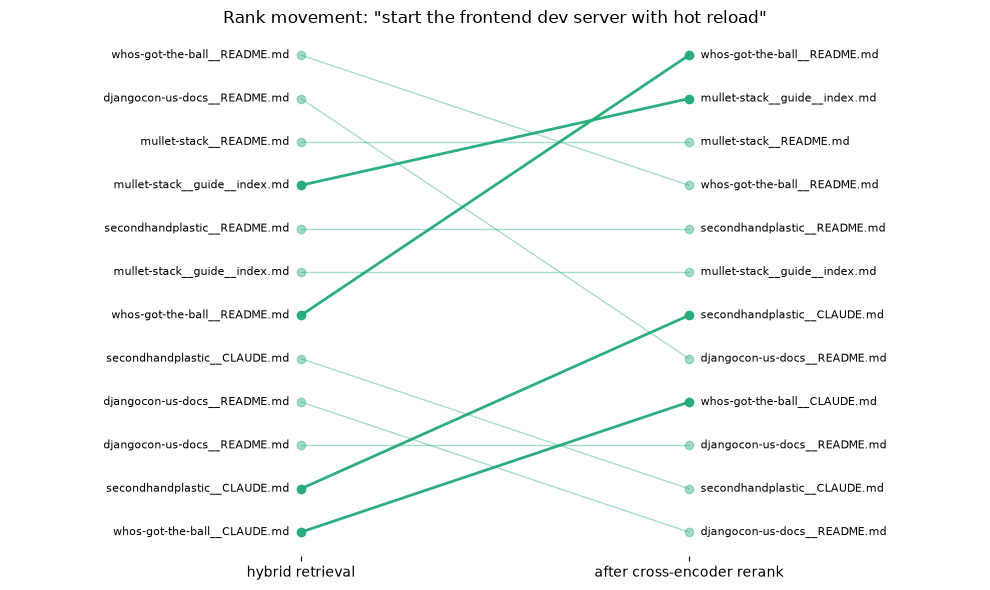

In [16]:
q = "start the frontend dev server with hot reload"
before = hybrid(q, k=12, pool=12)
after  = rerank(q, before)

figures.rank_movement(q, before, after, chunks)

That query is in here because three separate repos in this corpus run a Vite dev server
on port 5173. Retrieval cannot tell them apart, and there is no right answer without
knowing which project was meant. The gap is in the question rather than the retriever,
so the fix is metadata filtering, meaning scoping the search to one repo, rather than a
better model.

---
## 5. Evaluation

Everything above is a plausible story. None of it is evidence.

An eval turns "this feels better" into a number. It works like a test suite: write down
what the right answer is, then check how often you get it.

**Step one: write down the right answer.** `queries.json` holds 18 questions. Each one
carries a **marker**, the exact string that has to appear in a retrieved chunk for the
search to count as correct.

```
question: "how do I wipe my local database and start over?"
marker:   "make reset"
```

If a retrieved chunk contains `make reset`, the search found the answer. That is the
whole labelling scheme.

In [17]:
import json

queries = json.loads(pathlib.Path("queries.json").read_text())
item = queries[1]

print("question:", item["q"])
print("marker:  ", repr(item["marker"]), "\n")

for i in top_k(dense_scores(item["q"]), 5):
    found = "FOUND" if item["marker"] in chunks[i]["text"] else "     "
    print(f"  {found}  {chunks[i]['file']}")

question: how do I wipe my local database and start over?
marker:   'make reset' 

  FOUND  secondhandplastic__CLAUDE.md
         secondhandplastic__README.md
         whos-got-the-ball__README.md
         secondhandplastic__CLAUDE.md
         whos-got-the-ball__README.md


**Step two: count.** Run that check for all 18 questions and take the fraction that found
their marker in the top 5. That is **recall@5**: of the answers that exist, how many did
we find, looking at the 5 results the prompt has room for.

**MRR** adds *how high*: score 1 if the right chunk ranked first, 1/2 if second, 1/3 if
third, 0 if it never appeared, then average.

In [18]:
def evaluate(retrieve, k=5):
    hits, rr = 0, []
    for item in queries:
        got = [chunks[i]["text"] for i in retrieve(item["q"], k)]
        ranks = [r for r, text in enumerate(got, 1) if item["marker"] in text]
        hits += bool(ranks)
        rr.append(1 / ranks[0] if ranks else 0.0)
    return hits / len(queries), float(np.mean(rr))

methods = {
    "dense only":     lambda q, k: top_k(dense_scores(q), k),
    "BM25 only":      lambda q, k: top_k(bm25_scores(q), k),
    "hybrid (RRF)":   hybrid,
    "hybrid + rerank": hybrid_reranked,
}
results = {name: evaluate(fn) for name, fn in methods.items()}
for name, (r, m) in results.items():
    print(f"{name:<18} recall@5 {r:.2f}   MRR {m:.2f}")

dense only         recall@5 0.78   MRR 0.69
BM25 only          recall@5 0.78   MRR 0.62
hybrid (RRF)       recall@5 0.89   MRR 0.65
hybrid + rerank    recall@5 0.94   MRR 0.85


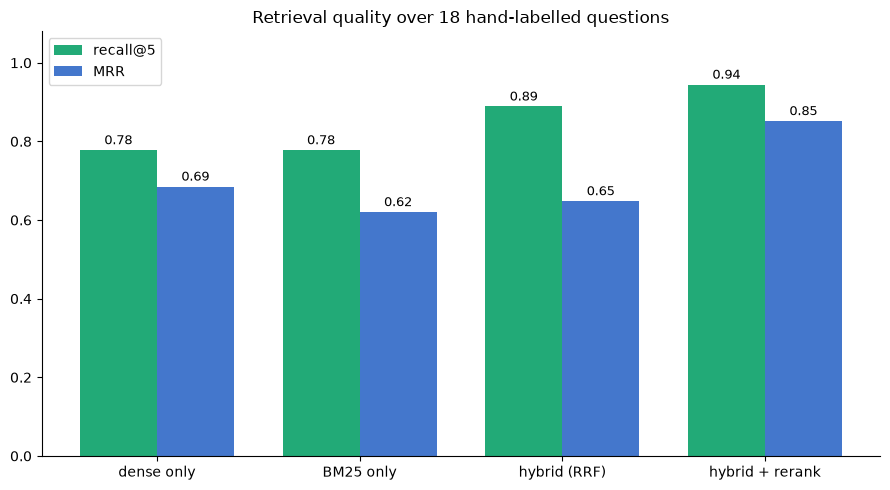

In [19]:
figures.retrieval_quality(results, len(queries))

Three things worth reading off that chart:

1. **Dense and BM25 tie at 0.78, and fail on different questions.** That is the argument
   for hybrid search. If they failed on the same questions, fusing them would buy
   nothing. The failure list below is the evidence.
2. **Fusion buys recall, not ranking.** Hybrid lifts recall 0.78 to 0.89, while MRR
   *drops* to 0.65. RRF is good at getting the right chunk somewhere into the top 5, but
   it has no idea which of the five is best.
3. **The cross-encoder fixes ranking.** MRR 0.65 to 0.85 over the same candidates,
   mostly just reordering. That matters because the prompt has room for 3 chunks, not 25.

In [20]:
# Where does each method actually break? This is the useful half of an eval.
for item in queries:
    row = {}
    for name, fn in methods.items():
        got = [chunks[i]["text"] for i in fn(item["q"], 5)]
        row[name] = any(item["marker"] in text for text in got)
    if not all(row.values()):
        missed = ", ".join(n for n, ok in row.items() if not ok)
        print(f'MISS  "{item["q"]}"\n      failed for: {missed}')
        if item["note"]:
            print(f'      note: {item["note"]}')
        print()

MISS  "how do I wipe my local database and start over?"
      failed for: BM25 only
      note: query shares almost no words with the answer



MISS  "what port does local Postgres listen on?"
      failed for: dense only
      note: lexical: a rare exact token, BM25 territory



MISS  "what does it mean for someone to have the ball?"
      failed for: BM25 only



MISS  "start the frontend dev server with hot reload"
      failed for: dense only
      note: AMBIGUOUS ON PURPOSE: three separate repos run Vite on 5173



MISS  "where do the TypeScript types stop lining up with the Python ones?"
      failed for: dense only



MISS  "what colors does the site use?"
      failed for: BM25 only, hybrid (RRF)
      note: 'colors' vs 'palette' is a small semantic gap BM25 cannot cross



MISS  "which parts of the site should I leave alone?"
      failed for: dense only, BM25 only, hybrid (RRF), hybrid + rerank
      note: nothing retrieves this: the answer's heading says 'intentional, do not fix' and the question says 'leave alone'. Dense ranks it 8th.



The last one is the most instructive, because *every* method missed it. The question is
"which parts of the site should I leave alone?" and the passage answering it is headed
"Content that is intentional, do not 'fix'". Same meaning, almost no shared words.

BM25 has nothing to match on. The embedding does better, ranking it **8th out of 199**,
so it sees the connection. But 8th is outside the top 5, and fusion and reranking can only
reorder what retrieval already surfaced. Miss it there and every later stage inherits the
miss. A bigger model would not fix it; the first two items in section 7 would.

### What the eval is actually for

Catching a change that made things worse.

Say you decide smaller chunks would be more precise, and drop the chunk size from 900
characters to 200. That is a one-word edit, it runs without error, and every answer still
looks plausible. The eval is the only thing that tells you what it cost.

In [21]:
before = evaluate(hybrid)[0]

chunks = build_chunks(max_chars=200, overlap=30)     # the "improvement"
E = embed([c["text"] for c in chunks])
index_bm25(chunks)
after = evaluate(hybrid)[0]

chunks = build_chunks()                              # put it back
E = embed([c["text"] for c in chunks])
index_bm25(chunks)

print(f"chunk size 900 -> recall@5 {before:.2f}")
print(f"chunk size 200 -> recall@5 {after:.2f}")
print(f"\nverdict: {'REGRESSION' if after < before else 'fine'}, "
      f"{(before-after)*len(queries):.0f} of {len(queries)} questions newly broken")

chunk size 900 -> recall@5 0.89
chunk size 200 -> recall@5 0.78

verdict: REGRESSION, 2 of 18 questions newly broken


That is the argument for evals in one cell. The change was reasonable, the code ran, and
it quietly broke several questions.

Two caveats. With 18 questions each one is worth 0.06 recall, so this eval can say "200 is
a bad idea" but cannot referee 0.89 against 0.94. And it measures retrieval only, which is
the half you can check without a language model.

*In production:* RAGAS is the usual package, and it scores the generation half too. That
needs a language model to grade the answers, so it costs money per run, and a hand-rolled
retrieval eval like this one stays free and stays honest.

---
## 6. The generation half

No API call here, so nothing needs a key. That is partly the point: retrieval is where
the engineering lives, and it can be measured without a language model in the loop. The G
in RAG is one request with the retrieved text in the prompt.

In [22]:
question = "why is the rate limiter backed by the database instead of kept in memory?"
picked   = hybrid_reranked(question, k=3)

context = "\n\n---\n\n".join(
    f"[source: {chunks[i]['file']}]\n{chunks[i]['text']}" for i in picked
)
prompt = "\n".join([
    "Answer the question using only the sources below.",
    "Cite the source filename for each claim.",
    "If the sources do not contain the answer, say so instead of guessing.",
    "",
    "SOURCES:",
    context,
    "",
    f"QUESTION: {question}",
])
print(prompt)

Answer the question using only the sources below.
Cite the source filename for each claim.
If the sources do not contain the answer, say so instead of guessing.

SOURCES:
[source: secondhandplastic__README.md]
### Why the pooler

Zero-downtime deploys run old and new instances at once, and Supabase's direct
connection allows far too few connections for that — so the app connects through the
transaction pooler on 6543. Server-side prepared statements are disabled to suit it.
Migrations are the exception: DDL through the transaction pooler is unreliable, so
`CS_MIGRATION_DATABASE_URL` should point at the direct or session connection on 5432.

Nothing may assume a single process. Most migrations must be additive-only, aside
from the `post_deploy` exception above; the app does no schema work at startup; and
`app/ratelimit.py` is Postgres-backed rather than in-memory, so limits are shared
and survive a restart.

---

[source: secondhandplastic__CLAUDE.md]
## Platform constraints that shape 

Three lines in that prompt each prevent a specific failure:

1. **"using only the sources below"** keeps the answer tied to what you retrieved.
   Without it the model answers from pretraining, hiding retrieval failures.
2. **"cite the source filename"** makes claims checkable. A citation that does not match
   the retrieved text is a cheap signal something was invented.
3. **"say so instead of guessing"** gives the model an exit, because a confident wrong
   answer is worse than "I don't know."

Sending it is `client.messages.create(model="claude-opus-5", ...)` with that string as the
user message.

**Worth knowing:** good retrieval does not guarantee a good answer. The right chunk can
be in the prompt and the model still gets it wrong, which is why RAG eval has a second
half, **faithfulness**: is every claim in the answer supported by the retrieved text?
That one needs a second model to score, so it is named here rather than built.

---
## 7. Four things worth knowing next

Named here so the terms are familiar when you meet them. The first two would move the
numbers on this corpus most.

- **Contextual retrieval**: prefix each chunk with a sentence saying where it came from
  before embedding it. Fixes the weakness in section 1, where a chunk cut from the middle
  of a file loses the context that made it make sense.
- **Metadata filtering**: scope the search to one repo. Section 4 had a question no
  retriever can answer without it.
- **Query rewriting**: expand the question before searching, so "how do I run this" gains
  some content words.
- **Late interaction (ColBERT)**: a vector per token instead of per chunk. Near
  cross-encoder quality at closer to bi-encoder speed.

---
## 8. Keeping the index fresh

One thing this notebook quietly dodges: the embeddings were computed once, and the moment
anyone commits to one of those repos they are out of date.

Re-embedding all 199 chunks takes seconds here. On a real corpus it is slow and, if you
are paying per token to embed, expensive. So production systems re-embed only what
changed, which needs each chunk to have a stable identity. Hashing the text works, and it
handles the awkward case for free: edit one paragraph and the chunks around it shift, so
their text changes and their hashes change with them.

In [23]:
import hashlib

def chunk_id(c):
    return hashlib.sha256(c["text"].encode()).hexdigest()[:12]

index = {chunk_id(c): c for c in chunks}      # what is already embedded

edited = build_chunks()                        # pretend one file just changed
edited[7] = {**edited[7], "text": edited[7]["text"] + " A sentence someone just added."}

fresh = [c for c in edited if chunk_id(c) not in index]
gone  = set(index) - {chunk_id(c) for c in edited}

print(f"{len(edited)} chunks, {len(fresh)} need embedding, {len(gone)} to delete")
print(f"saved: {(1 - len(fresh)/len(edited)) * 100:.0f}% of the embedding work")

199 chunks, 1 need embedding, 1 to delete
saved: 99% of the embedding work


The rest of the machinery follows from that. A push triggers the job, changed chunks get
embedded, deleted ones get removed from the index, and BM25 has to be rebuilt regardless,
because document frequency and average length are corpus-wide statistics.

The one that catches people: **changing the embedding model means re-embedding
everything.** Vectors from two different models are not comparable, so there is no
incremental path, and a half-migrated index returns nonsense rather than failing loudly.
Worth storing the model name alongside the vectors so the mismatch is at least detectable.

## The short version

Almost none of the work is in the vector math. It is in cutting documents sensibly,
running keyword search alongside semantic search, and writing down 18 labelled questions
so you have a number to point at when someone proposes a change.